# KIARA — Swin Transformer + RAAE for Diabetic Retinopathy Classification
### Knowledge-based Intelligent Analysis for Retinal Assessment — RAAE-Enhanced Variant

**Backbone:** `swin_base_patch4_window7_224` (via `timm`)
**Preprocessing:** Retina Anatomy-Aware Enhancement (RAAE) — **precomputed offline** in `RAAE_Preprocessing2.ipynb`
**Framework:** PyTorch
**Dataset:** APTOS 2019 Blindness Detection (`mariaherrerot/aptos2019` layout)
**Task:** 5-class diabetic retinopathy severity classification

---

## Pipeline

```
APTOS CSV labels
      |
      v
RAAE-enhanced image folders (RAAE_train_images / RAAE_valid_images)
      |
      v
PyTorch Dataset (PIL.Image.open -> RGB -> torchvision transforms)
      |
      v
Swin Transformer
      |
      v
Training -> Evaluation -> Inference
```

RAAE (circular retina crop, illumination correction, CLAHE, edge-preserving denoising,
Frangi vessel enhancement, adaptive gamma correction) has **already been applied offline**
by the separate `RAAE_Preprocessing2.ipynb` notebook and saved as a Kaggle dataset
(`RAAE_Images`, with `RAAE_train_images` / `RAAE_valid_images` subfolders). This notebook
does **not** perform any RAAE processing itself — it simply loads the already-enhanced
PNGs, trains, and evaluates the Swin Transformer.

| Class | Meaning |
|---|---|
| 0 | No DR |
| 1 | Mild |
| 2 | Moderate |
| 3 | Severe |
| 4 | Proliferative DR |


In [10]:
!pip install -q timm==1.0.11
!pip install -q torchmetrics==1.4.2
!pip install -q scikit-learn==1.5.2
!pip install -q tqdm==4.66.5
!pip install -q scikit-image==0.24.0
!pip install -q opencv-python-headless==4.10.0.84

print("Dependencies installed successfully.")

Dependencies installed successfully.


In [20]:
import os
import time
import random
import warnings

import numpy as np
import pandas as pd

from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

import timm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    cohen_kappa_score,
)

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

print(f"PyTorch version : {torch.__version__}")
print(f"timm version     : {timm.__version__}")


PyTorch version : 2.10.0+cu128
timm version     : 1.0.11


In [22]:
train_df = pd.read_csv(TRAIN_CSV)
valid_df = pd.read_csv(VALID_CSV)

# Point directly at the precomputed RAAE-enhanced images.
train_df["file_path"] = train_df["id_code"].apply(
    lambda x: os.path.join(TRAIN_IMG_DIR, f"{x}.png")
)
valid_df["file_path"] = valid_df["id_code"].apply(
    lambda x: os.path.join(VALID_IMG_DIR, f"{x}.png")
)

print(f"Train samples: {len(train_df)}")
print(f"Valid samples: {len(valid_df)}")
train_df.head()


Train samples: 2930
Valid samples: 366


,id_code,diagnosis,file_path
0,1ae8c165fd53,2,/kaggle/input/RAAE_Images/RAAE_train_images/1a...
1,1b329a127307,1,/kaggle/input/RAAE_Images/RAAE_train_images/1b...
2,1b32e1d775ea,4,/kaggle/input/RAAE_Images/RAAE_train_images/1b...
3,1b3647865779,0,/kaggle/input/RAAE_Images/RAAE_train_images/1b...
4,1b398c0494d1,0,/kaggle/input/RAAE_Images/RAAE_train_images/1b...


Training class distribution:
  0 (No DR            ):  1434 images (48.94%)
  1 (Mild             ):   300 images (10.24%)
  2 (Moderate         ):   808 images (27.58%)
  3 (Severe           ):   154 images (5.26%)
  4 (Proliferative DR ):   234 images (7.99%)


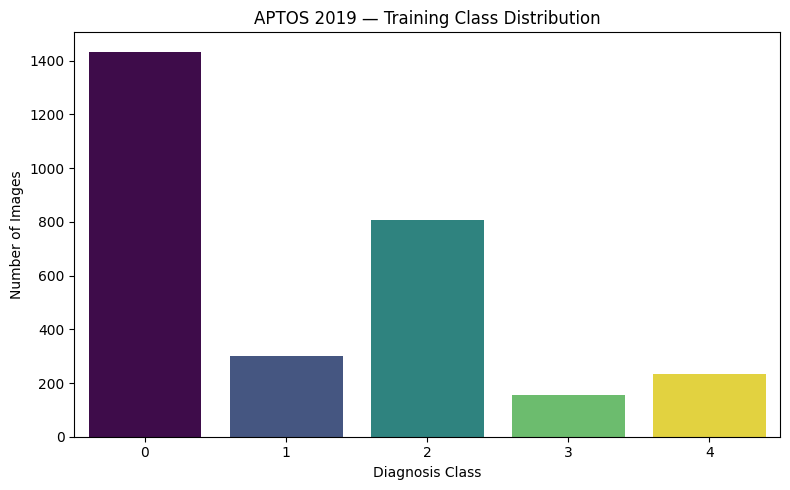

In [23]:
class_counts = train_df["diagnosis"].value_counts().sort_index()

print("Training class distribution:")
for cls_idx, count in class_counts.items():
    print(f"  {cls_idx} ({CLASS_NAMES[cls_idx]:<17}): {count:5d} images "
          f"({100 * count / len(train_df):.2f}%)")

plt.figure(figsize=(8, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index,
            palette="viridis", legend=False)
plt.xlabel("Diagnosis Class")
plt.ylabel("Number of Images")
plt.title("APTOS 2019 — Training Class Distribution")
plt.tight_layout()
plt.show()


In [24]:
train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

valid_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Train transform:\n", train_transform)
print("\nValid transform:\n", valid_transform)


Train transform:
 Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.05, 0.05))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Valid transform:
 Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [25]:
class APTOSDataset(Dataset):
    """Loads already RAAE-enhanced PNGs and their labels. No on-the-fly
    image processing of any kind happens here — RAAE was applied offline."""

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]["file_path"]
        label = self.dataframe.iloc[idx]["diagnosis"]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)


In [27]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    # only print directories, and a peek at file count/sample so it stays short
    depth = root.count(os.sep) - "/kaggle/input".count(os.sep)
    if depth <= 3:
        png_count = sum(1 for f in files if f.endswith(".png"))
        print("  " * depth + f"{root}  ({png_count} png files)" if png_count else "  " * depth + root)

/kaggle/input
  /kaggle/input/datasets
    /kaggle/input/datasets/pawanmanghnani
      /kaggle/input/datasets/pawanmanghnani/raae-images
    /kaggle/input/datasets/mariaherrerot
      /kaggle/input/datasets/mariaherrerot/aptos2019


In [32]:
# ============================================================
# Dataset + DataLoader (Swin + Precomputed RAAE Images)
# ============================================================

import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader


# ------------------------------------------------------------
# Paths to precomputed RAAE enhanced images
# ------------------------------------------------------------

TRAIN_IMG_DIR = "/kaggle/input/datasets/pawanmanghnani/raae-images/RAAE_train_images"
VALID_IMG_DIR = "/kaggle/input/datasets/pawanmanghnani/raae-images/RAAE_valid_images"


print("Train folder check:")
print(os.listdir(TRAIN_IMG_DIR)[:5])

print("\nValidation folder check:")
print(os.listdir(VALID_IMG_DIR)[:5])


# ------------------------------------------------------------
# Dataset class
# Loads already enhanced RAAE images
# NO RAAE PIPELINE HERE
# ------------------------------------------------------------

class APTOSDataset(Dataset):

    def __init__(self, dataframe, img_dir, transform=None):

        self.dataframe = dataframe.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform


    def __len__(self):
        return len(self.dataframe)


    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        image_id = row["id_code"]
        label = row["diagnosis"]

        img_path = os.path.join(
            self.img_dir,
            image_id + ".png"
        )

        image = Image.open(img_path).convert("RGB")


        if self.transform:
            image = self.transform(image)


        return image, torch.tensor(label, dtype=torch.long)



# ------------------------------------------------------------
# Create datasets
# ------------------------------------------------------------

train_dataset = APTOSDataset(
    train_df,
    TRAIN_IMG_DIR,
    transform=train_transform
)


valid_dataset = APTOSDataset(
    valid_df,
    VALID_IMG_DIR,
    transform=valid_transform
)


print("--------------------------------")
print("Train dataset size:", len(train_dataset))
print("Valid dataset size:", len(valid_dataset))
print("--------------------------------")



# ------------------------------------------------------------
# Sanity check
# ------------------------------------------------------------

sample_img, sample_label = train_dataset[0]

print("Image shape:", sample_img.shape)
print("Label:", sample_label)



# ------------------------------------------------------------
# DataLoaders
# ------------------------------------------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)


valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)



print("--------------------------------")
print("Train batches:", len(train_loader))
print("Valid batches:", len(valid_loader))
print("--------------------------------")

Train folder check:
['6dcde47060f9.png', 'b49b2fac2514.png', 'af6166d57f13.png', '8d13c46e7d75.png', 'c3b15bf9b4bc.png']

Validation folder check:
['17f6c7072f61.png', '0243404e8a00.png', '0083ee8054ee.png', '0ac436400db4.png', '0d0a21fd354f.png']
--------------------------------
Train dataset size: 2930
Valid dataset size: 366
--------------------------------
Image shape: torch.Size([3, 224, 224])
Label: tensor(2)
--------------------------------
Train batches: 92
Valid batches: 12
--------------------------------


In [33]:
swin_model = timm.create_model(
    "swin_base_patch4_window7_224",
    pretrained=True,
    num_classes=NUM_CLASSES,
).to(device)

total_params = sum(p.numel() for p in swin_model.parameters())
trainable_params = sum(p.numel() for p in swin_model.parameters() if p.requires_grad)

print(f"Model               : swin_base_patch4_window7_224")
print(f"Total Parameters    : {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

# Quick forward-pass sanity check
sample_images, _ = next(iter(train_loader))
with torch.no_grad():
    sample_outputs = swin_model(sample_images.to(device))
print(f"Sample output shape : {sample_outputs.shape}")

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Model               : swin_base_patch4_window7_224
Total Parameters    : 86,748,349
Trainable Parameters: 86,748,349
Sample output shape : torch.Size([32, 5])


In [34]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    swin_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
)

# Guardrail: confirm optimizer and model parameters are the same objects
optimizer_param_ids = {id(p) for group in optimizer.param_groups for p in group["params"]}
model_param_ids = {id(p) for p in swin_model.parameters()}
assert optimizer_param_ids == model_param_ids, "Optimizer is not bound to swin_model's parameters!"

print("Loss Function :", criterion)
print("Optimizer     : AdamW")
print("Scheduler     : CosineAnnealingLR")
print("Epochs        :", EPOCHS)
print("Checkpoint    :", BEST_MODEL_PATH)
print("Optimizer <-> model parameter check passed.")


Loss Function : CrossEntropyLoss()
Optimizer     : AdamW
Scheduler     : CosineAnnealingLR
Epochs        : 10
Checkpoint    : best_swin_raae.pth
Optimizer <-> model parameter check passed.


In [35]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        progress_bar.set_postfix(loss=loss.item(), acc=100 * correct / total)

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def validate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc, all_labels, all_preds


print("train_one_epoch and validate functions defined.")


train_one_epoch and validate functions defined.


In [36]:
best_accuracy = 0.0

train_losses = []
valid_losses = []
train_accuracies = []
valid_accuracies = []

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 40)

    train_loss, train_acc = train_one_epoch(swin_model, train_loader, criterion, optimizer, device)
    valid_loss, valid_acc, y_true, y_pred = validate(swin_model, valid_loader, criterion, device)

    scheduler.step()

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
    train_accuracies.append(train_acc)
    valid_accuracies.append(valid_acc)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.4f}")
    print(f"Valid Loss : {valid_loss:.4f}")
    print(f"Valid Acc  : {valid_acc:.4f}")

    if valid_acc > best_accuracy:
        best_accuracy = valid_acc
        torch.save(swin_model.state_dict(), BEST_MODEL_PATH)
        print("Best KIARA Swin + RAAE model saved!")

print("\nKIARA Swin + RAAE Training Complete!")
print(f"Best Validation Accuracy: {best_accuracy:.4f}")



Epoch 1/10
----------------------------------------


Training:   0%|          | 0/92 [00:00<?, ?it/s]

Train Loss : 0.7753
Train Acc  : 0.7174
Valid Loss : 0.6287
Valid Acc  : 0.7623
Best KIARA Swin + RAAE model saved!

Epoch 2/10
----------------------------------------


Training:   0%|          | 0/92 [00:00<?, ?it/s]

Train Loss : 0.5556
Train Acc  : 0.7904
Valid Loss : 0.6094
Valid Acc  : 0.7705
Best KIARA Swin + RAAE model saved!

Epoch 3/10
----------------------------------------


...

Train Loss : 0.3292
Train Acc  : 0.8741
Valid Loss : 0.4586
Valid Acc  : 0.8497
Best KIARA Swin + RAAE model saved!

Epoch 9/10
----------------------------------------


Training:   0%|          | 0/92 [00:00<?, ?it/s]

Train Loss : 0.3069
Train Acc  : 0.8877
Valid Loss : 0.4483
Valid Acc  : 0.8388

Epoch 10/10
----------------------------------------


Training:   0%|          | 0/92 [00:00<?, ?it/s]

Train Loss : 0.3015
Train Acc  : 0.8863
Valid Loss : 0.4556
Valid Acc  : 0.8415

KIARA Swin + RAAE Training Complete!
Best Validation Accuracy: 0.8497


Evaluating:   0%|          | 0/12 [00:00<?, ?it/s]

VALIDATION SET — EVALUATION SUMMARY (KIARA Swin + RAAE)
Accuracy               : 0.8497
Precision (weighted)   : 0.8405
Recall (weighted)      : 0.8497
F1-Score (weighted)    : 0.8351
Quadratic Weighted Kappa (QWK): 0.8981

Classification Report:

                  precision    recall  f1-score   support

           No DR       0.97      0.99      0.98       172
            Mild       0.76      0.65      0.70        40
        Moderate       0.74      0.90      0.81       104
          Severe       0.57      0.18      0.28        22
Proliferative DR       0.76      0.57      0.65        28

        accuracy                           0.85       366
       macro avg       0.76      0.66      0.69       366
    weighted avg       0.84      0.85      0.84       366



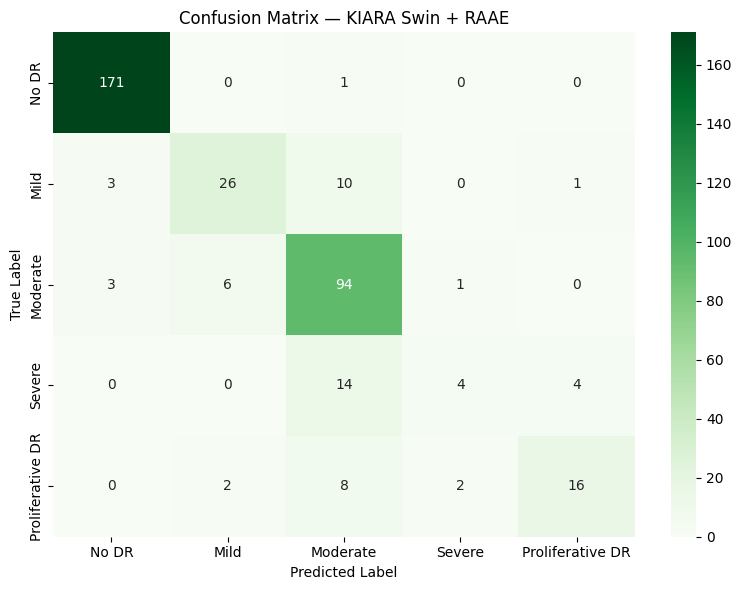

In [37]:
swin_model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
swin_model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in tqdm(valid_loader, desc="Evaluating"):
        images = images.to(device)
        outputs = swin_model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
recall = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
qwk = cohen_kappa_score(all_labels, all_preds, weights="quadratic")

print("=" * 55)
print("VALIDATION SET — EVALUATION SUMMARY (KIARA Swin + RAAE)")
print("=" * 55)
print(f"Accuracy               : {acc:.4f}")
print(f"Precision (weighted)   : {precision:.4f}")
print(f"Recall (weighted)      : {recall:.4f}")
print(f"F1-Score (weighted)    : {f1:.4f}")
print(f"Quadratic Weighted Kappa (QWK): {qwk:.4f}")
print("=" * 55)

print("\nClassification Report:\n")
print(classification_report(
    all_labels, all_preds,
    target_names=[CLASS_NAMES[i] for i in range(NUM_CLASSES)],
    zero_division=0,
))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=[CLASS_NAMES[i] for i in range(NUM_CLASSES)],
            yticklabels=[CLASS_NAMES[i] for i in range(NUM_CLASSES)])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — KIARA Swin + RAAE")
plt.tight_layout()
plt.show()


In [38]:
torch.save(swin_model.state_dict(), FINAL_MODEL_PATH)

torch.save({
    "model_state_dict": swin_model.state_dict(),
    "model_name": "swin_base_patch4_window7_224",
    "preprocessing": "RAAE (Retina Anatomy-Aware Enhancement, precomputed offline)",
    "num_classes": NUM_CLASSES,
    "class_names": CLASS_NAMES,
    "img_size": IMG_SIZE,
    "imagenet_mean": IMAGENET_MEAN,
    "imagenet_std": IMAGENET_STD,
    "best_val_accuracy": float(best_accuracy),
    "qwk": float(qwk),
}, CHECKPOINT_PATH)

print(f"Final model weights saved to : {FINAL_MODEL_PATH}")
print(f"Rich checkpoint saved to     : {CHECKPOINT_PATH}")


Final model weights saved to : kiara_swin_raae_final.pth
Rich checkpoint saved to     : kiara_swin_raae_checkpoint.pth


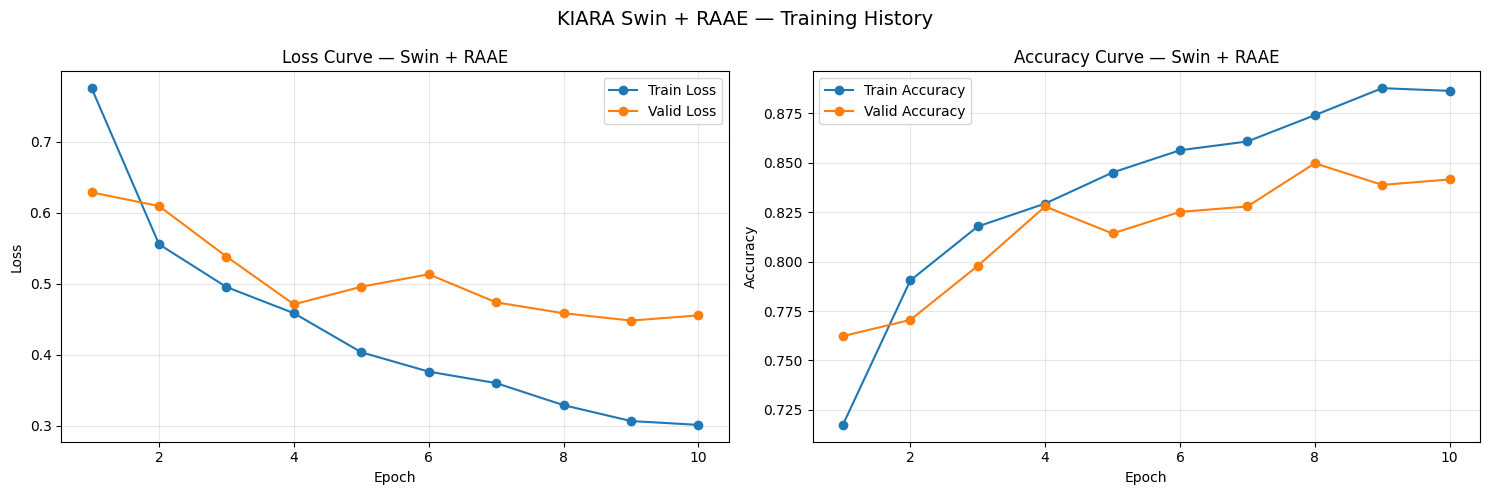

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
epochs_range = range(1, len(train_losses) + 1)

axes[0].plot(epochs_range, train_losses, label="Train Loss", marker="o")
axes[0].plot(epochs_range, valid_losses, label="Valid Loss", marker="o")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curve — Swin + RAAE")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, train_accuracies, label="Train Accuracy", marker="o")
axes[1].plot(epochs_range, valid_accuracies, label="Valid Accuracy", marker="o")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy Curve — Swin + RAAE")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("KIARA Swin + RAAE — Training History", fontsize=14)
plt.tight_layout()
plt.show()


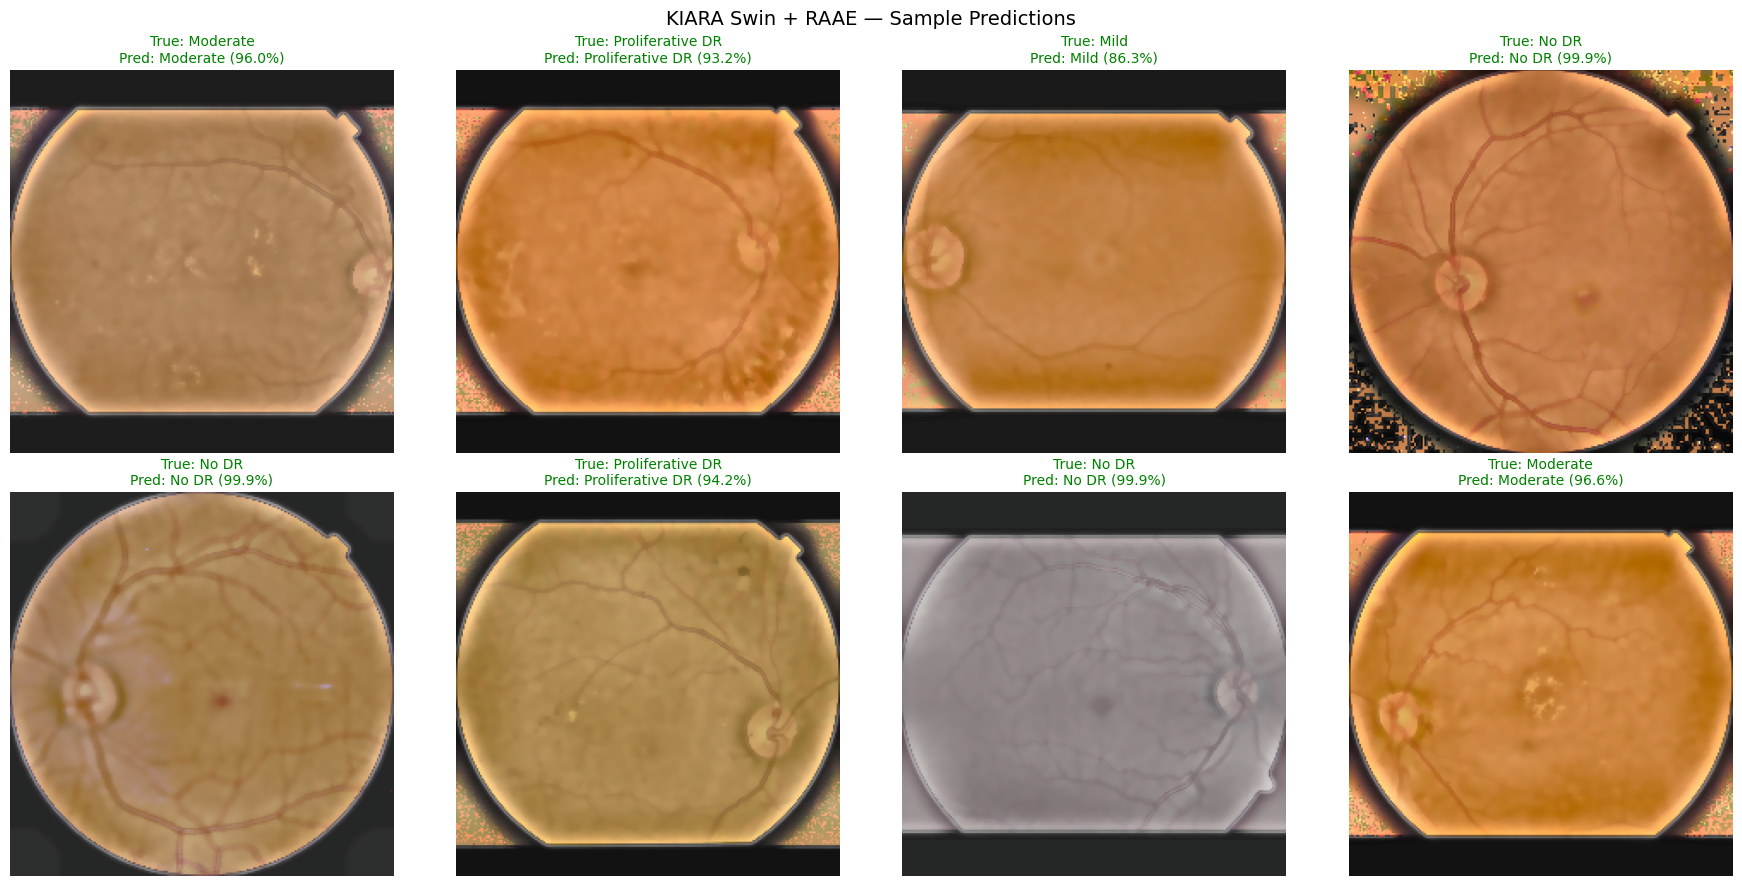

In [40]:
def denormalize(tensor_img, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    img = tensor_img.clone().cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(std) + np.array(mean)
    return np.clip(img, 0, 1)


vis_images, vis_labels = next(iter(valid_loader))
vis_images_device = vis_images.to(device)

swin_model.eval()
with torch.no_grad():
    outputs = swin_model(vis_images_device)
    probs = torch.softmax(outputs, dim=1)
    confidences, preds = torch.max(probs, dim=1)

n_display = min(8, len(vis_images))
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i in range(n_display):
    img = denormalize(vis_images[i])
    true_label = vis_labels[i].item()
    pred_label = preds[i].item()
    confidence = confidences[i].item()

    color = "green" if true_label == pred_label else "red"

    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(
        f"True: {CLASS_NAMES[true_label]}\nPred: {CLASS_NAMES[pred_label]} ({confidence*100:.1f}%)",
        color=color, fontsize=10,
    )

plt.suptitle("KIARA Swin + RAAE — Sample Predictions", fontsize=14)
plt.tight_layout()
plt.show()


In [44]:
def predict_image(image_path, model=swin_model, transform=valid_transform, device=device):
    """Run inference on a single already-RAAE-enhanced image.
    No RAAE processing happens here — the image at image_path must already
    be enhanced (i.e. come from RAAE_train_images / RAAE_valid_images, or a
    new image processed through RAAE_Preprocessing2.ipynb first)."""

    model.eval()

    image = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)

    pred = torch.argmax(probs, dim=1).item()

    return {
        "prediction": pred,
        "prediction_label": CLASS_NAMES[pred],
        "confidence": probs[0][pred].item(),
    }


# Example usage on a validation sample:
# result = predict_image(valid_df.iloc[0]["file_path"])
# print(result)


In [46]:
# ============================================================
# Swin + RAAE Single Image Prediction
# ============================================================

swin_model.eval()

idx = 10

img, label = valid_dataset[idx]

with torch.no_grad():

    output = swin_model(
        img.unsqueeze(0).to(device)
    )

    probs = torch.softmax(output, dim=1)


pred = torch.argmax(probs, dim=1).item()

confidence = probs[0][pred].item() * 100


print("True class :", label.item())
print("Predicted  :", pred)
print("Confidence :", f"{confidence:.2f}%")

True class : 0
Predicted  : 0
Confidence : 98.81%
